# Creating an example availability matrix

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import pyplot as plt

# prepare links to the data csv files
from collections import defaultdict

folder = Path("historical_data")
usecols = [
    "Datetime (UTC)",
    "Carbon Intensity gCO₂eq/kWh (direct)",
    "Carbon Intensity gCO₂eq/kWh (LCA)",
]
df_dict = dict()

for p in folder.iterdir():
    if p.name not in ['CR_2022_hourly.csv', 'AU-TAS_2022_hourly.csv', 'AU-SA_2022_hourly.csv', 'CA-QC_2022_hourly.csv']:
        val = pd.read_csv(
            p,
            usecols=usecols + ["Country", "Zone Id"],
            parse_dates=["Datetime (UTC)"],
        ).rename(columns={
            "Datetime (UTC)": "datetime",
            "Carbon Intensity gCO₂eq/kWh (direct)": "CI_direct",
            "Carbon Intensity gCO₂eq/kWh (LCA)": "CI_LCA"
        }).set_index("datetime")
        _country = val["Country"].iloc[0]
        _zone_id = val["Zone Id"].iloc[0]
        _df = val[['CI_direct', 'CI_LCA']]
        df_dict[_country+"_"+_zone_id] = _df

In [2]:
god_df = pd.concat(
    [
        df[["CI_direct"]]
        .rename(columns={"CI_direct": country})
        for country, df in df_dict.items()
    ],
    axis=1,
    sort=False,
)

In [3]:
import random
from datetime import timedelta

power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round
n_rows = 100


ghg_god_df = god_df * power * round_duration / 1000

In [6]:
list_countries = ['Great Britain_GB', 'Germany_DE', 'Ireland_IE', 'France_FR', 'Finland_FI', 'Sweden_SE-SE3', 'Belgium_BE']
_df = ghg_god_df[list_countries]
tot_list_hours = _df.index.to_list()
max_window = 100
max_time_delta = timedelta(hours=max_window - 1)

# start_time = random.choice(tot_list_hours[: -(max_window - 1)])
start_time = tot_list_hours[0]
# Truncating the dataframe
_trunc_arr = _df.truncate(before=start_time, after=start_time + max_time_delta)


# Sort indices along each column in descending order
sorted_indices = np.argsort(_trunc_arr.values, axis=0)

# Select the top k indices for each column
top_k_indices = sorted_indices[:50, :]

# Create a mask for the top k elements
mask = np.zeros_like(_trunc_arr.values, dtype=bool)
for col in range(_trunc_arr.shape[1]):
    mask[top_k_indices[:, col], col] = True

# Retain the original order of elements
result = np.where(
    mask, _trunc_arr.values, 0.0
)
_trunc_arr.index = _trunc_arr.index.strftime('%d/%m/%y %H')

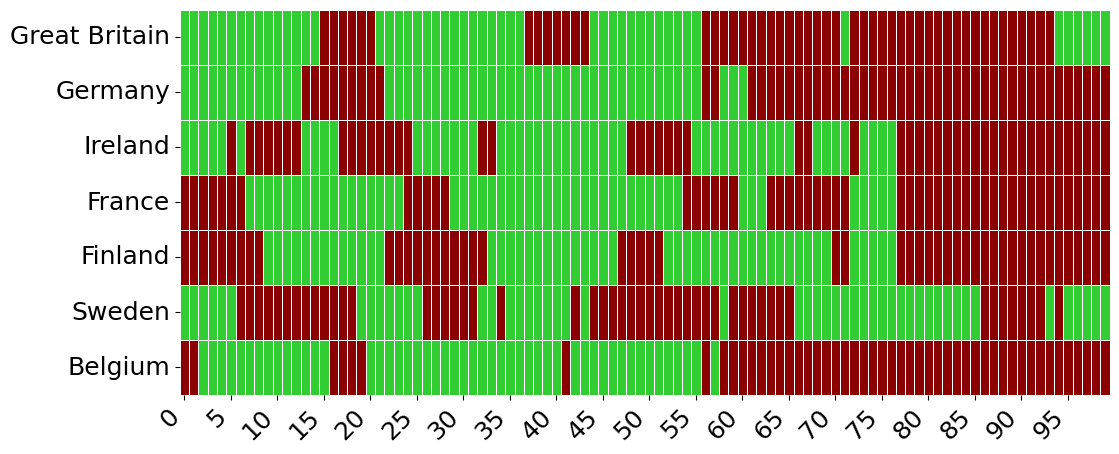

In [ ]:
folder = 'availability_matrices/'
key_word = 'sample_mat'

similarity_matrix=pd.DataFrame(data=mask.astype(np.int8), index=_trunc_arr.index, columns=['Great Britain', 'Germany', 'Ireland', 'France', 'Finland', 'Sweden', 'Belgium']).transpose()
plt.figure(figsize=(12, 5))
ax = plt.subplot()

# cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) 
cmap = LinearSegmentedColormap.from_list("rwg", ["darkred", "limegreen"], N=2)
sns.heatmap(similarity_matrix.astype(int), annot=False, fmt='d', cbar=False, cmap=cmap, linewidths=0.5, linecolor='white', ax=ax) # create heatmap

if not isinstance(similarity_matrix.columns[0], np.int64):
    plt.xticks(rotation=45, ha='right')  # rotate x-axis labels to diagonal
xticks = ax.get_xticks()
# xticks = xticks[::2]
xticks = np.arange(similarity_matrix.shape[1])[::5]
ax.set_xticks(xticks + 0.5)
ax.set_xticklabels(xticks, fontsize=18)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=18)
# ax.set_xticks(xticks) # set new xticks
plt.xlabel("")
plt.savefig(folder+'/'+key_word+'.png', bbox_inches='tight')
plt.show() 